In [27]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler



In [46]:
attributes = ['ID', 'diagnosis','radius1','texture1','perimeter1','area1','smoothness1','compactness1','concavity1','concave_points1','symmetry1','fractal dimension1','radius2','texture2','perimeter2','area2','smoothness2','compactness2','concavity2','concave_points2','symmetry2','fractal dimension2','radius3','texture3','perimeter3','area3','smoothness3','compactness3','concavity3','concave_points3'
,'symmetry3','fractal dimension3']

unsplit_data = pd.read_csv('/wdbc.data', names = attributes)

In [47]:
unsplit_data['diagnosis'] = np.where(data['diagnosis'] == 'B', 0, 1)

In [48]:
unsplit_data.isnull().sum()

ID                    0
diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal dimension3    0
dtype: int64

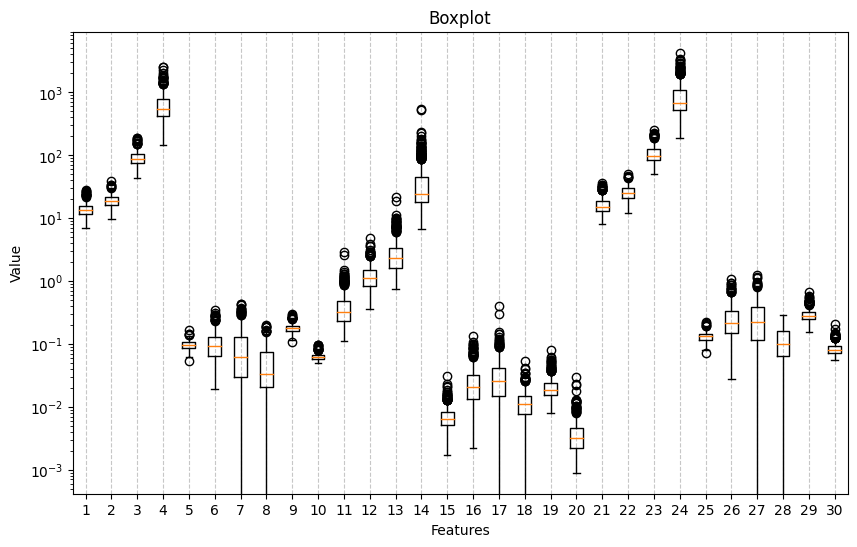

In [49]:
# Create a boxplot
plt.figure(figsize=(10, 6))  # Adjust the figure size if needed
boxplot = plt.boxplot(unsplit_data.iloc[:,2:])

# Set the y-scale to log
plt.yscale("log")

# Add a grid for better readability
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels and a title
plt.xlabel("Features")
plt.ylabel("Value")
plt.title("Boxplot")

plt.show()

In [68]:
# applying minmaxscaler then splitting the data
unsplit_data_scaler = MinMaxScaler()
unsplit_data.iloc[:,2:] = unsplit_data_scaler.fit_transform(data.iloc[:,2:])
X_train, X_test, y_train, y_test = train_test_split(unsplit_data.iloc[:, 2:], unsplit_data.iloc[:, 1], test_size=0.1, random_state=0)

,ID,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal dimension3
0,842302,M,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,842517,M,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,84300903,M,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,84348301,M,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,84358402,M,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,926682,M,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,926954,M,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,927241,M,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


Text(0.5, 1.0, 'score vs k')

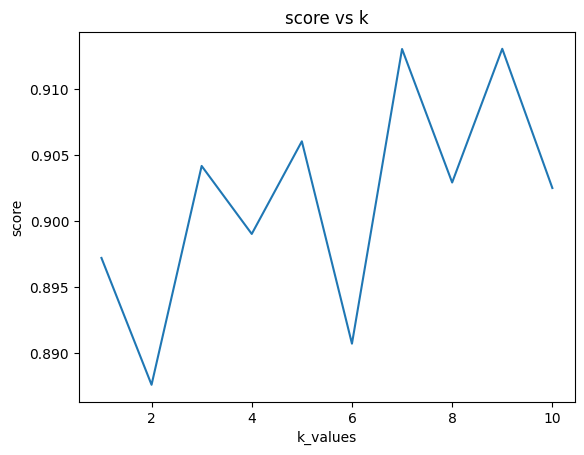

In [80]:
knn = KNeighborsClassifier()
k_values = range(1,11)
param = {'n_neighbors': k_values}

grid_search = GridSearchCV(knn, param, cv=5, scoring='f1')
grid_search = grid_search.fit(X_train, y_train)
plt.plot(k_values, grid_search.cv_results_['mean_test_score'])
plt.xlabel("k_values")
plt.ylabel("score")
plt.title("score vs k")

In [82]:
print(grid_search.best_params_)
model = grid_search.best_estimator_
y_predict = model.predict(X_test)
f1_score(y_test, y_predict)

{'n_neighbors': 9}


0.9302325581395349